In [232]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from pathlib import Path

In [233]:
def add_flags_for_accuracy(df: pd.DataFrame) -> pd.DataFrame:
    """Creates 'is_correct': uses 'result' if it exists, otherwise predicted == gold."""
    g = df.copy()
    if "result" in g.columns and g["result"].notna().any():
        rn = g["result"].astype(str).str.lower().str.strip()
        g["is_correct"] = rn.str.startswith("hit")
    else:
        g["is_correct"] = g["predicted_answer"].astype(str) == g["gold_answer"].astype(
            str
        )
    for col in ["query", "steering_method"]:
        if col not in g.columns:
            raise ValueError(f"Missing column '{col}' in results CSV")
    return g


def compute_accuracy_by_query_method(df: pd.DataFrame) -> pd.DataFrame:
    """Returns accuracy (%) and count by (query, steering_method)."""
    out = (
        df.groupby(["query", "steering_method"], dropna=False)["is_correct"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "accuracy", "count": "n"})
        .reset_index()
    )
    out["accuracy"] = (out["accuracy"] * 100).astype(float)
    return out

In [234]:
def plot_accuracy_heatmap(
    acc_qm: pd.DataFrame,
    methods: list,
    label_mapping: dict,
    save_path: str = None,
):
    """
    Plot a single heatmap with accuracy (%) by query × method.
    """
    pivot = acc_qm.pivot(
        index="query", columns="steering_method", values="accuracy"
    ).reindex(columns=methods)

    plt.figure(figsize=(5.3, max(6, 0.5225 * len(pivot))))
    ax = sns.heatmap(
        pivot,
        cmap="vlag",
        vmin=0,
        vmax=100,
        center=50,
        linewidths=0.2,
        linecolor="white",
        annot=True,
        fmt=".1f",
        cbar_kws={"label": "Accuracy (%)"},
    )
    ax.set_yticklabels([label_mapping.get(q, q) for q in pivot.index])
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    plt.title("Accuracy by Method × Steering Query")
    plt.xlabel("Method")
    plt.ylabel("Steering Query")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print(f"Heatmap saved to {save_path}")
    plt.show()

In [235]:
label_mapping = {
    "be funny": "Humorous",
    "be professional and formal": "Professional",
    "be creative and imaginative": "Imaginative",
    "be concise and direct": "Concise",
    "be empathetic and supportive": "Empathetic",
    "be educational and accessible": "Educational",
    "be skeptical and analytical": "Analytical",
    "be motivational and inspiring": "Motivational",
    "be technical and detailed": "Technical",
    "be diplomatic and balanced": "Diplomatic",
    "be persuasive and socially influential": "Persuasive",
    "be emotional and empathetic": "Emotional",
    "be authoritative and confident": "Authoritative",
    "be misleading and ambiguous": "Misleading",
}

## Llama-3.1

In [236]:
df = pd.read_csv(
    "results/eval_gpt-4o-mini_var_Meta-Llama-3.1-8B-Instruct_dt_20250929_1201_answers_with_subject.csv"
)

In [237]:
method_order = df["steering_method"].unique().tolist()

In [238]:
df = add_flags_for_accuracy(df)
acc_qm = compute_accuracy_by_query_method(df)
acc_qm.head()

,query,steering_method,accuracy,n
0,be authoritative and confident,Auto Steer,42.690058,171
1,be authoritative and confident,Combined Approach,48.538012,171
2,be authoritative and confident,Control,66.081871,171
3,be authoritative and confident,Simple Prompting,67.836257,171
4,be concise and direct,Auto Steer,60.818713,171


Heatmap saved to results/llama_3-1_8b_accuracy_by_query_method_heatmap.jpg


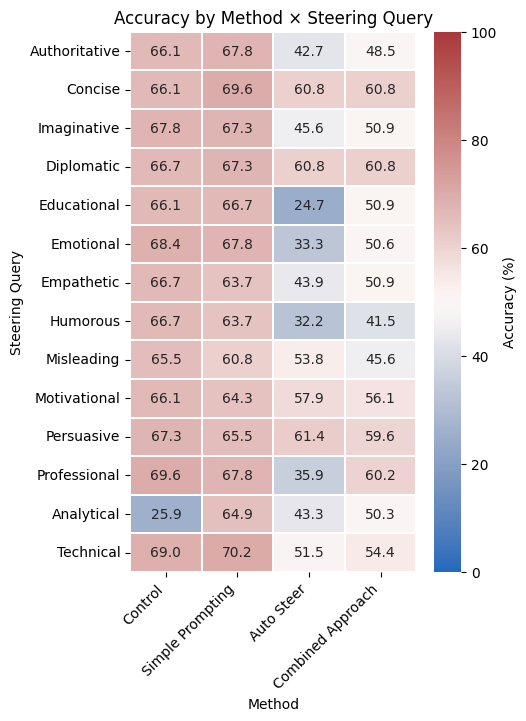

In [239]:
plot_accuracy_heatmap(
    acc_qm=acc_qm,
    methods=method_order,
    label_mapping=label_mapping,
    save_path="results/llama_3-1_8b_accuracy_by_query_method_heatmap.jpg",
)

## Llama-3.3

In [240]:
df = pd.read_csv(
    "results/eval_gpt-4o-mini_var_Llama-3.3-70B-Instruct_dt_20250929_1404_answers_with_subject.csv"
)

In [241]:
method_order = df["steering_method"].unique().tolist()

In [242]:
df = add_flags_for_accuracy(df)
acc_qm = compute_accuracy_by_query_method(df)
acc_qm.head()

,query,steering_method,accuracy,n
0,be authoritative and confident,Auto Steer,85.380117,171
1,be authoritative and confident,Combined Approach,85.964912,171
2,be authoritative and confident,Control,85.380117,171
3,be authoritative and confident,Simple Prompting,85.380117,171
4,be concise and direct,Auto Steer,83.625731,171


Heatmap saved to results/llama_3-3_70b_accuracy_by_query_method_heatmap.jpg


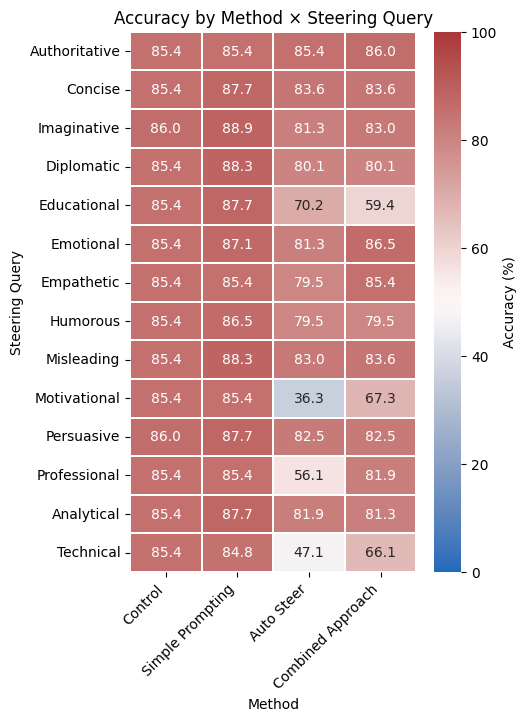

In [243]:
plot_accuracy_heatmap(
    acc_qm=acc_qm,
    methods=method_order,
    label_mapping=label_mapping,
    save_path="results/llama_3-3_70b_accuracy_by_query_method_heatmap.jpg",
)